# Evaluation 
The main matrix evaluation used are: 
- F1-score (Metrics Utama) 
- Precision 
- Recall
- AUC-ROC


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 1. Logistic Regression

In [ ]:
X_test_df = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')['Revenue'].astype(int).values

# Convert booleans/objects to numeric
X_test_numeric = X_test_df.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

# CRITICAL FIX: Convert to numpy array to remove feature name mismatch
X_test_final = X_test_numeric.values

In [4]:
with open('model/model_logistic_regression.pkl', 'rb') as f:
    model = pickle.load(f)

In [6]:
y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]

c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Machine Learning\AOL\Prediction-Model-for-Analyzing-Users-Behaviour\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Machine Learning\AOL\Prediction-Model-for-Analyzing-Users-Behaviour\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [7]:
print("--- LOGISTIC REGRESSION REPORT ---")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

--- LOGISTIC REGRESSION REPORT ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2059
           1       0.75      0.51      0.61       382

    accuracy                           0.90      2441
   macro avg       0.83      0.74      0.78      2441
weighted avg       0.89      0.90      0.89      2441

AUC-ROC Score: 0.9134


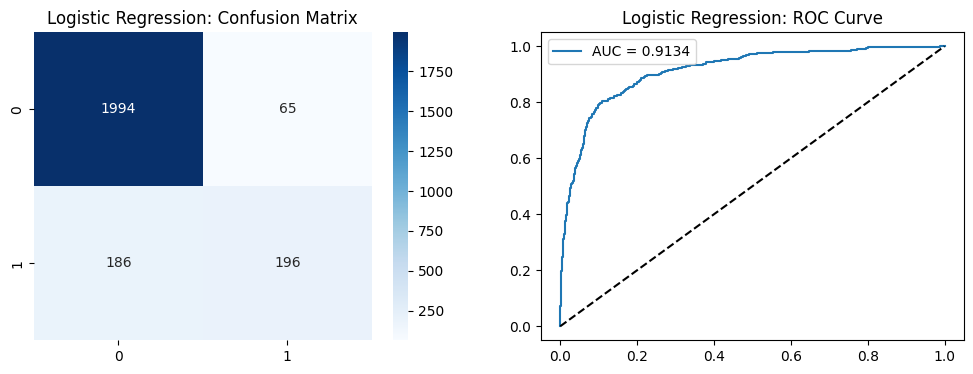

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression: Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Logistic Regression: ROC Curve')
ax[1].legend()
plt.show()

# 2. Random Forest

In [9]:
with open('model/model_random_forest.pkl', 'rb') as f:
    model = pickle.load(f)

In [10]:
y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]

c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Machine Learning\AOL\Prediction-Model-for-Analyzing-Users-Behaviour\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Machine Learning\AOL\Prediction-Model-for-Analyzing-Users-Behaviour\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [11]:
print("--- RANDOM FOREST REPORT ---")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

--- RANDOM FOREST REPORT ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2059
           1       0.70      0.55      0.62       382

    accuracy                           0.89      2441
   macro avg       0.81      0.75      0.78      2441
weighted avg       0.89      0.89      0.89      2441

AUC-ROC Score: 0.8949


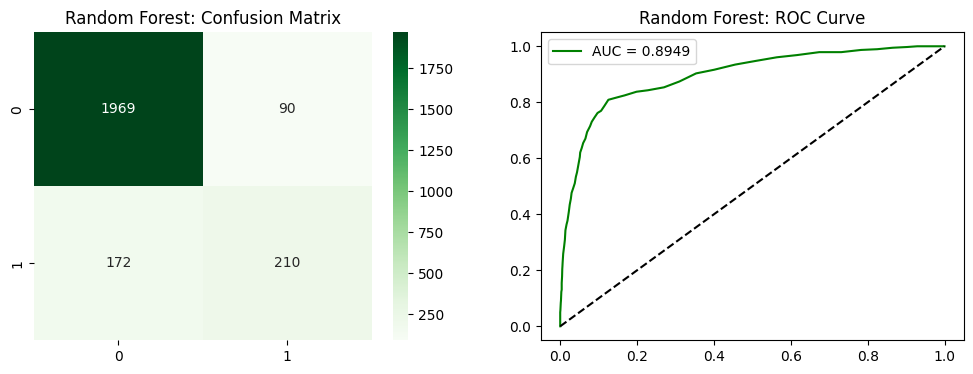

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Random Forest: Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, color='green', label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Random Forest: ROC Curve')
ax[1].legend()
plt.show()

# 3.  XGBoost

In [13]:
with open('model/model_xgboost.pkl', 'rb') as f:
    model = pickle.load(f)

In [14]:
y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]

In [16]:
print("--- XGBoost REPORT ---")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")

--- XGBoost REPORT ---
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      2059
           1       0.59      0.78      0.67       382

    accuracy                           0.88      2441
   macro avg       0.77      0.84      0.80      2441
weighted avg       0.90      0.88      0.89      2441

AUC-ROC Score: 0.8824


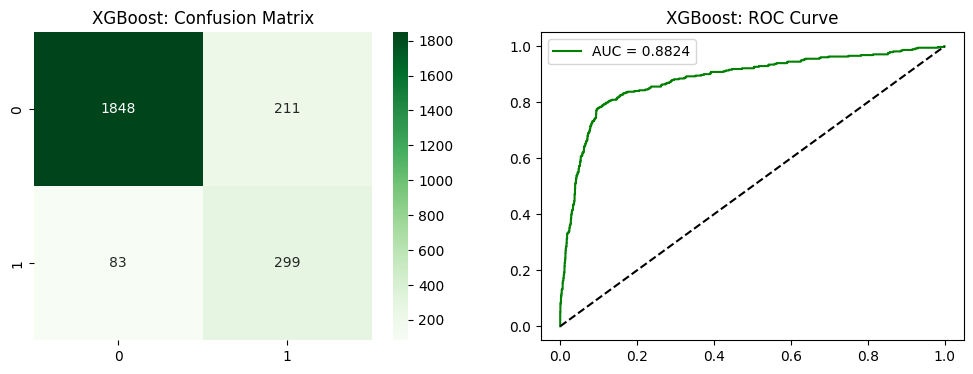

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('XGBoost: Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, color='green', label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('XGBoost: ROC Curve')
ax[1].legend()
plt.show()

# Conclusion
The logistic regression was the highest AUC score with the 91% followed by random forest with the 89% then XGBoost with the 88% 